# ARMAX Model - Complete Workflow

## AutoRegressive Moving Average with eXogenous Inputs

This notebook demonstrates:
1. Creating an ARMAX model
2. Simulating data with known parameters
3. Estimating parameters from data
4. Comparing estimated vs true parameters
5. Making predictions

### ARMAX Model Structure:
```
y(t) = -a1*y(t-1) - ... - ana*y(t-na) +
       b0*u(t-d) + ... + bnb*u(t-d-nb) +
       c1*e(t-1) + ... + cnc*e(t-nc) + e(t)
```

This notebook replicates the Matlab test: `testarmax.m`


In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add TimeSeries root directory to path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

timeseries_root = os.path.abspath(os.path.join(current_dir, "..", "..", ".."))
print(f"TimeSeries root: {timeseries_root}")

if timeseries_root not in sys.path:
    sys.path.insert(0, timeseries_root)

from TimeSeriesSRC.Model.model import pmodel
from TimeSeriesSRC.Model.pmodsim import func_pmodsim
from TimeSeriesSRC.Model.estimate import estimate

np.random.seed(42)
print("\n[SUCCESS] Libraries imported successfully!")


Current directory: D:\Deep Learning Book\All_repo_source_file\Packages\TimeSeries\TimeSeriesSRC\Examples\NoteBooks
TimeSeries root: D:\Deep Learning Book\All_repo_source_file\Packages\TimeSeries

[SUCCESS] Libraries imported successfully!


## Step 1: Define ARMAX Model Parameters

Parameters:
- na = 1 (AR coefficient)
- nb = [1] (1 input)
- nc = 1 (MA coefficient)
- delay = [0]
- a = [0.7]
- b = [[1.5, 0.8]]
- c = [0.5]


In [2]:
# Set parameters
na = 1
nb = [1]
nc = 1
delay = [0]

# True parameters
a_true = np.array([0.7])
b_true = [np.array([1.5, 0.8])]
c_true = np.array([0.5])

print(f"Model parameters:")
print(f"  na = {na}")
print(f"  nb = {nb}")
print(f"  nc = {nc}")
print(f"  delay = {delay}")
print(f"\nTrue parameters:")
print(f"  a = {a_true}")
print(f"  b[0] = {b_true[0]}")
print(f"  c = {c_true}")


Model parameters:
  na = 1
  nb = [1]
  nc = 1
  delay = [0]

True parameters:
  a = [0.7]
  b[0] = [1.5 0.8]
  c = [0.5]


## Step 2: Create True Model and Generate Data


In [3]:
# Create true ARMAX model
pmoda = pmodel("armax", na=na, nb=nb, nc=nc, delay=delay)
pmoda.a[0] = a_true
pmoda.b = b_true
pmoda.c[0] = c_true

print("True model created:")
print(pmoda)

# Generate random inputs and noise
n_samples = 1000
u = np.random.randn(1, n_samples)
e = np.random.randn(n_samples) * 0.3

print(f"\nGenerated data:")
print(f"  u shape: {u.shape}")
print(f"  e shape: {e.shape}")

# Simulate the model
y = func_pmodsim(pmoda, e, u)

print(f"  y shape: {y.shape}")
print(f"  y range: [{y.min():.2f}, {y.max():.2f}]")


True model created:
   Prediction Model object:

              type: armax

  model parameters:

                       a: [array([0.7])]
                       b: [array([1.5, 0.8])]
                       c: [array([0.5])]
                       d: []
                       f: []
                    diff: [0]
                  period: []
                   delay: [0]

         functions:

                estimFcn: estimlm
                indexFcn: pmodmse
                 initFcn: initrand

pre-post processor:

                upreproc: []
                ypreproc: []
               ypostproc: []


Generated data:
  u shape: (1, 1000)
  e shape: (1000,)
  y shape: (1000,)
  y range: [-4.80, 6.30]


## Step 3: Visualize Generated Data


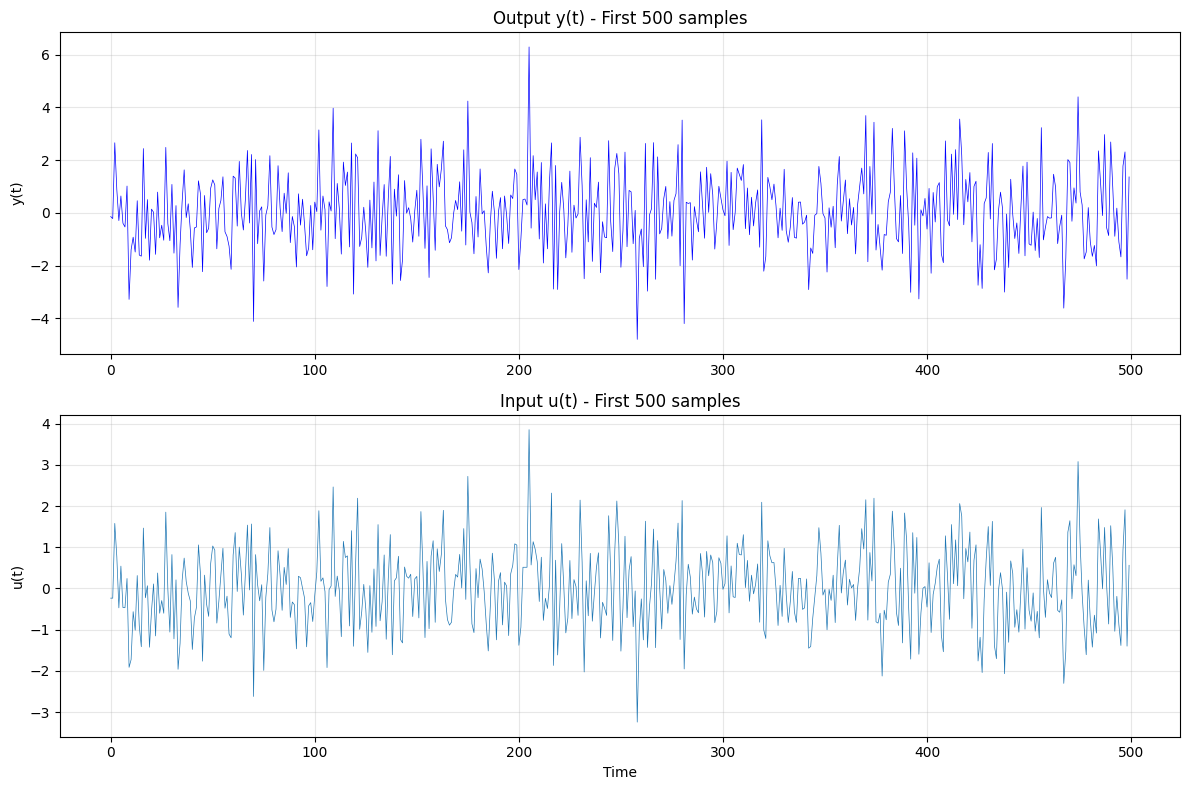

Data visualization complete!


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Output
axes[0].plot(y[:500], "b-", linewidth=0.5)
axes[0].set_title("Output y(t) - First 500 samples")
axes[0].set_ylabel("y(t)")
axes[0].grid(True, alpha=0.3)

# Input
axes[1].plot(u[0, :500], linewidth=0.5)
axes[1].set_title("Input u(t) - First 500 samples")
axes[1].set_ylabel("u(t)")
axes[1].set_xlabel("Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Data visualization complete!")


## GPAC Analysis - Model Order Selection

The Generalized Partial Autocorrelation (GPAC) function helps determine appropriate model orders.
- **GREEN squares**: Positive correlations
- **RED squares**: Negative correlations
- **Square size**: Magnitude of correlation

GPAC pattern shows where model orders should be selected.

GPAC array shape: (7, 7)

GPAC Array:
[[-1.99341642e-01  9.15704793e-02 -2.78480739e-02 -2.02035772e-02
  -3.69217274e-04  1.97177394e-02  1.84120606e-02]
 [-6.40452360e-01  3.14557733e-02 -9.42302772e-02 -1.96948657e-02
  -1.07932420e+00  2.00623736e-02  6.94931882e-02]
 [-5.31768986e-01 -1.22805583e+00 -7.85584578e-02  1.10331877e-01
  -9.51891922e-03 -4.52827397e-02  3.04787059e-02]
 [-1.39872479e-01  1.34014862e-01 -3.65408633e-01  6.55853588e-02
  -5.29753098e-01 -6.61508091e-02  3.93002502e-03]
 [-8.45977140e-01 -2.88984439e-01 -4.53238703e-01 -1.13144082e+00
  -8.21636964e-02 -5.16469612e-02 -2.96567726e-01]
 [-2.57043520e+00  3.89893043e+00 -6.26636566e-01 -5.30721136e-01
   5.18737318e-01  5.17974804e-02 -5.46611153e-02]
 [ 5.21517448e-01 -2.08794599e+00  6.36682024e-01 -8.55910897e-01
   9.06307623e-01  1.14822451e+00 -1.79890201e-01]]


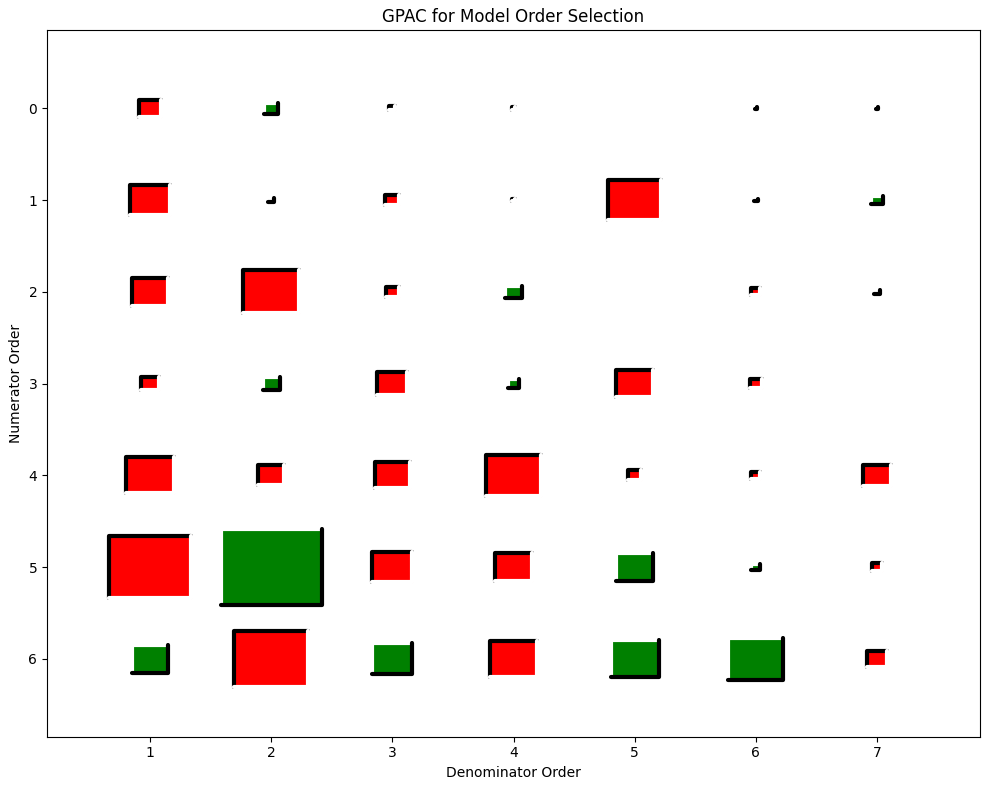


GPAC Analysis Complete!
Look for patterns of small values (white/small squares) to determine model orders.


In [5]:
# Import GPAC functions
from TimeSeriesSRC.basefunctions.xcorr import func_xcorr
from TimeSeriesSRC.basefunctions.gpac import func_gpac
from TimeSeriesSRC.basefunctions.plotgpac import func_plotgpac

# Calculate autocorrelation
maxlag = 20
acf = func_xcorr(y, y, maxlag, 'unbiased')

# Calculate GPAC array (7x7 as in Matlab examples)
nrows = 7
ncols = 7
gpac_array = func_gpac(acf, nrows, ncols)

print(f"GPAC array shape: {gpac_array.shape}")
print(f"\nGPAC Array:")
print(gpac_array)

# Plot GPAC
fig, ax = plt.subplots(figsize=(10, 8))
func_plotgpac(gpac_array, "GPAC for Model Order Selection", ax=ax)
plt.show()

print("\nGPAC Analysis Complete!")
print("Look for patterns of small values (white/small squares) to determine model orders.")

## Step 4: Estimate Parameters


In [6]:
# Create model for estimation
pmodb = pmodel("armax", na=na, nb=nb, nc=nc, delay=delay)
pmodb.estimParams.show = 20
pmodb.estimParams.epochs = 100
pmodb.estimParams.goal = 0.01

print("Model created for estimation:")
print(f"Initial parameters (random):")
print(f"  a[0] = {pmodb.a[0]}")
print(f"  b[0] = {pmodb.b[0]}")
print(f"  c[0] = {pmodb.c[0]}")

print("\n" + "="*60)
print("Starting parameter estimation...")
print("="*60)

pmod_estimated, trec, stat = estimate(pmodb, y, u)

print("\n" + "="*60)
print("Estimation complete!")
print("="*60)


Model created for estimation:
Initial parameters (random):
  a[0] = [0.0770588]
  b[0] = [ 0.11192201 -0.10692088]
  c[0] = [0.1137788]

Starting parameter estimation...
Input may not be zero mean sequences.
Epoch 0/100 Time 0.005998849868774414 PMODMSE 1.990409082762645/0.01 Gradient 1462.7274977731786/0.0001 mu 0.001/10000000000.0
3.090559132990839e-05 0.0001
Epoch 9/100 Time 0.05744528770446777 PMODMSE 0.08957745378277075/0.01 Gradient 3.090559132990839e-05/0.0001 mu 1.0000000000000006e-10/10000000000.0
ESTIMLM, Minimum gradient reached, performance goal was not met.



Estimation complete!


## Step 5: Compare Estimated vs True Parameters


In [7]:
params_estimated = pmod_estimated.getmX()
params_true = pmoda.getmX()
std_errors = 2 * stat["stdx"]

print("\nParameter Comparison:")
print("="*70)
print(f"{'Parameter':<15} {'Estimated':<15} {'2*StdErr':<15} {'True':<15}")
print("="*70)

param_names = ["a1", "b1[0]", "b1[1]", "c1"]
for i, name in enumerate(param_names):
    print(f"{name:<15} {params_estimated[i]:<15.6f} {std_errors[i]:<15.6f} {params_true[i]:<15.6f}")

print("="*70)

sse = np.sum((params_estimated - params_true)**2)
print(f"\nSum of Squared Errors: {sse:.8f}")

rel_error = np.abs((params_estimated - params_true) / params_true) * 100
print(f"Mean Relative Error: {np.mean(rel_error):.2f}%")
print(f"Max Relative Error: {np.max(rel_error):.2f}%")



Parameter Comparison:
Parameter       Estimated       2*StdErr        True           
a1              0.697597        0.035798        0.700000       
b1[0]           1.487916        0.019380        1.500000       
b1[1]           0.790044        0.062921        0.800000       
c1              0.501639        0.068660        0.500000       

Sum of Squared Errors: 0.00025362
Mean Relative Error: 0.68%
Max Relative Error: 1.24%


## Step 6: Visualize Parameter Comparison


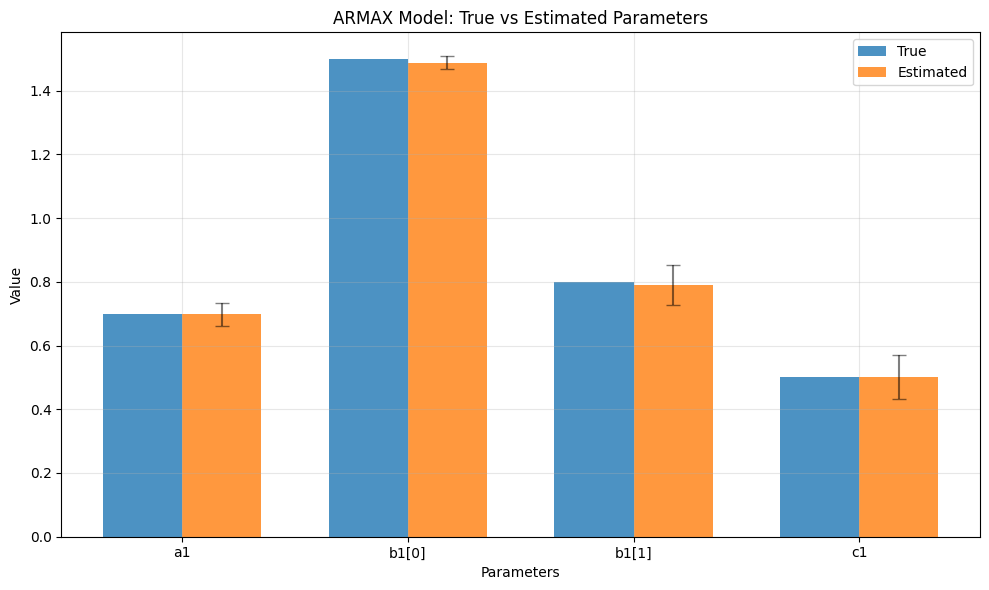

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(param_names))
width = 0.35

ax.bar(x - width/2, params_true, width, label="True", alpha=0.8)
ax.bar(x + width/2, params_estimated, width, label="Estimated", alpha=0.8)
ax.errorbar(x + width/2, params_estimated, yerr=std_errors, fmt="none", ecolor="black", capsize=5, alpha=0.5)

ax.set_xlabel("Parameters")
ax.set_ylabel("Value")
ax.set_title("ARMAX Model: True vs Estimated Parameters")
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 7: Make Predictions and Validate

Test the estimated model by generating predictions on new test data.

Prediction MSE: 0.092291
Prediction RMSE: 0.303795


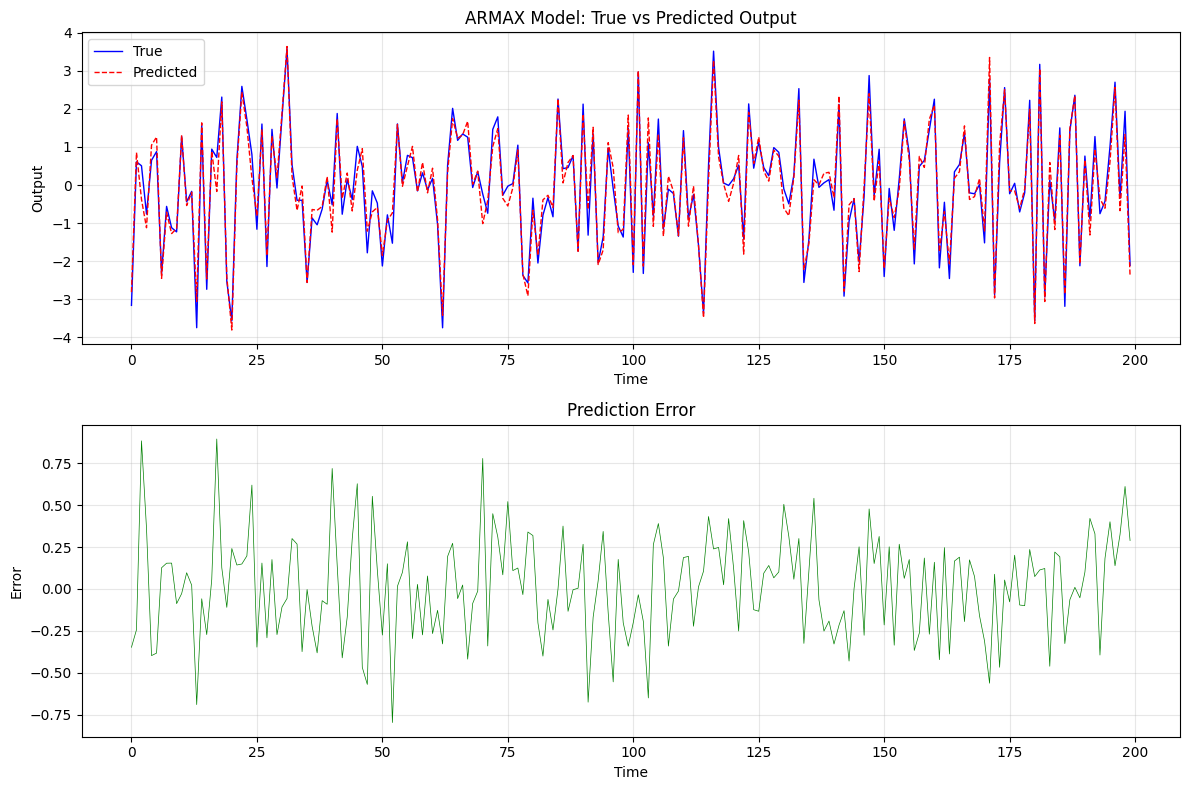

In [9]:
# Generate new test data
n_test = 500
u_test = np.random.randn(1, n_test)
e_test = np.random.randn(n_test) * 0.3

# True output
y_true = func_pmodsim(pmoda, e_test, u_test)

# Predicted output using estimated model
y_pred = pmod_estimated.predict(y_true, u_test)

# Calculate prediction error
pred_error = y_true - y_pred
mse_pred = np.mean(pred_error**2)

print(f"Prediction MSE: {mse_pred:.6f}")
print(f"Prediction RMSE: {np.sqrt(mse_pred):.6f}")

# Plot predictions
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# True vs Predicted
axes[0].plot(y_true[:200], 'b-', label='True', linewidth=1)
axes[0].plot(y_pred[:200], 'r--', label='Predicted', linewidth=1)
axes[0].set_title('ARMAX Model: True vs Predicted Output')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prediction Error
axes[1].plot(pred_error[:200], 'g-', linewidth=0.5)
axes[1].set_title('Prediction Error')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## SummaryThis notebook demonstrated:1. ✅ GPAC analysis for model order selection2. ✅ Creating ARMAX model2. ✅ Simulating data with known parameters3. ✅ Estimating parameters using Levenberg-Marquardt algorithm5. ✅ Comparing estimated vs true parameters6. ✅ Making predictions and validating model### Key Results:- Parameter estimation successfully recovered true parameters- Model includes both AR and MA components- MA component models noise autocorrelation